In [7]:
import hashlib
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

notebooks_dir = Path.cwd()
PROJECT_ROOT = notebooks_dir.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
qa_candidates = sorted(DATA_DIR.glob("NvidiaTechQA*.zip"))
corpus_candidates = sorted(DATA_DIR.glob("corpus*.zip"))

if not qa_candidates or not corpus_candidates:
    raise FileNotFoundError(
        "Place the NVIDIA TechQA ZIP and corpus ZIP in DATA_DIR, then rerun this cell."
    )

QA_ZIP = qa_candidates[0]
CORPUS_ZIP = corpus_candidates[0]

print("QA archive:    ", QA_ZIP)
print("Corpus archive:", CORPUS_ZIP)

QA archive:     /home/cohle/machine_learning/supportbench/data/nvidia_techqa/raw/NvidiaTechQA.zip
Corpus archive: /home/cohle/machine_learning/supportbench/data/nvidia_techqa/raw/corpus.zip


In [10]:
with zipfile.ZipFile(CORPUS_ZIP) as z:
    corpus_members = [name for name in z.namelist() if name.endswith(".txt")]

print(f"Number of text documents in the corpus: {len(corpus_members)}")

Number of text documents in the corpus: 28481


In [15]:
qa.head()

,id,question,answer,is_impossible,contexts,context_count,context_filename,context_text,question_chars,question_words,answer_chars,answer_words,context_chars,context_words,normalized_question,normalized_answer
0,TRAIN_Q000,User environment variables no longer getting picked up after upgrade to 4.1.1.1 or 4.1.1.2?\n\n\n\nHave you found th...,"To work around the issue, set environment variables that are needed by the application directly in the instance with...",False,"[{'filename': 'swg21996508.txt', 'text': 'Title: IBM STREAMS 4.1.1.1 and 4.1.1.2 JOBS DO NOT INHERIT THE ENVIRONMEN...",1,swg21996508.txt,"Title: IBM STREAMS 4.1.1.1 and 4.1.1.2 JOBS DO NOT INHERIT THE ENVIRONMENT VARIABLES SET IN .BASHRC, WHEN STREAMS I...",460,88,233,31,1328,217.0,user environment variables no longer getting picked up after upgrade to 4.1.1.1 or 4.1.1.2? have you found that afte...,"to work around the issue, set environment variables that are needed by the application directly in the instance with..."
1,TRAIN_Q001,Netcool/Impact (all versions): How is the Exit() action function expected to work with User Defined Functions?\n\nNe...,This is because the Exit() parser function in IPL is designed to exit the immediate scope. To carry the action outsi...,False,"[{'filename': 'swg21675316.txt', 'text': 'Title: IBM Exit() action within User Defined Function in Impact Policy Lan...",1,swg21675316.txt,Title: IBM Exit() action within User Defined Function in Impact Policy Language - United States\n\nText:\nnetcool; i...,252,40,269,48,1979,254.0,netcool/impact (all versions): how is the exit() action function expected to work with user defined functions? netco...,this is because the exit() parser function in ipl is designed to exit the immediate scope. to carry the action outsi...
2,TRAIN_Q002,Why are replies going to the DLQ with reason 2189 MQRC_CLUSTER_RESOLUTION_ERROR\n\nI have changed my cluster receive...,-,True,[],0,<NA>,<NA>,553,96,1,0,<NA>,NaN,why are replies going to the dlq with reason 2189 mqrc_cluster_resolution_error i have changed my cluster receiver t...,-
3,TRAIN_Q003,How to configure SSL mutual authentication in IBM HTTP Server?\n\n\n\nWe are running IHS v7 and our application team...,The following steps help guide you through the proper set up of SSL within the IBM HTTP Server: \n\n 1. Confirm that...,False,"[{'filename': 'swg21179559.txt', 'text': 'Title: IBM Guide to properly setting up SSL within the IBM HTTP Server - U...",1,swg21179559.txt,Title: IBM Guide to properly setting up SSL within the IBM HTTP Server - United States\n\nText:\nssl; handshake; sec...,295,51,673,100,14422,1916.0,how to configure ssl mutual authentication in ibm http server? we are running ihs v7 and our application team has a ...,the following steps help guide you through the proper set up of ssl within the ibm http server: 1. confirm that the ...
4,TRAIN_Q004,Help with Action required for IIB H.E. V9 & WMB H.E. V8 for security vulnerabilities in Red Hat Linux (CVE-2018-6551...,-,True,[],0,<NA>,<NA>,429,75,1,0,<NA>,NaN,help with action required for iib h.e. v9 & wmb h.e. v8 for security vulnerabilities in red hat linux (cve-2018-6551...,-


In [12]:
qa_raw = pd.DataFrame(records)

qa = qa_raw.copy()
qa["context_count"] = qa["contexts"].map(len)
qa["context_filename"] = qa["contexts"].map(
    lambda xs: xs[0]["filename"] if xbs else pd.NA
)
qa["context_text"] = qa["contexts"].map(
    lambda xs: xs[0]["text"] if xs else pd.NA
)

def word_count(text):
    if not isinstance(text, str):
        return np.nan
    return len(re.findall(r"\b\w+\b", text))

qa["question_chars"] = qa["question"].str.len()
qa["question_words"] = qa["question"].map(word_count)
qa["answer_chars"] = qa["answer"].str.len()
qa["answer_words"] = qa["answer"].map(word_count)
qa["context_chars"] = qa["context_text"].str.len()
qa["context_words"] = qa["context_text"].map(word_count)

print("Shape:", qa.shape)
print("Context counts:")
display(qa["context_count"].value_counts().sort_index().to_frame("rows"))

def shorten(text, n=160):
    if not isinstance(text, str):
        return text
    one_line = re.sub(r"\s+", " ", text).strip()
    return one_line if len(one_line) <= n else one_line[:n] + "…"

preview = qa[["id", "question", "answer", "is_impossible", "context_filename"]].head(4).copy()
preview["question"] = preview["question"].map(shorten)
preview["answer"] = preview["answer"].map(shorten)
display(preview)

Shape: (910, 14)
Context counts:


,rows
context_count,
0,300
1,610


,id,question,answer,is_impossible,context_filename
0,TRAIN_Q000,User environment variables no longer getting picked up after upgrade to 4.1.1.1 or 4.1.1.2? Have you found that afte...,"To work around the issue, set environment variables that are needed by the application directly in the instance with...",False,swg21996508.txt
1,TRAIN_Q001,Netcool/Impact (all versions): How is the Exit() action function expected to work with User Defined Functions? Netco...,This is because the Exit() parser function in IPL is designed to exit the immediate scope. To carry the action outsi...,False,swg21675316.txt
2,TRAIN_Q002,Why are replies going to the DLQ with reason 2189 MQRC_CLUSTER_RESOLUTION_ERROR I have changed my cluster receiver t...,-,True,<NA>
3,TRAIN_Q003,How to configure SSL mutual authentication in IBM HTTP Server? We are running IHS v7 and our application team has a ...,The following steps help guide you through the proper set up of SSL within the IBM HTTP Server: 1. Confirm that the ...,False,swg21179559.txt


In [13]:
def normalize_text(text):
    """Removes extra white-spaces, converts to lowercase"""
    return re.sub(r"\s+", " ", str(text).strip().lower())

qa["normalized_question"] = qa["question"].map(normalize_text)
qa["normalized_answer"] = qa["answer"].map(normalize_text)

# Groups with the same question (if any)
question_groups = qa.groupby("normalized_question", dropna=False)
duplicate_question_groups = question_groups.filter(lambda g: len(g) > 1)

# Groups with question with contradictory sentiment (possible and impossible)
mixed_label_groups = [
    group for _, group in question_groups
    if len(group) > 1 and group["is_impossible"].nunique() > 1
]

possible = qa.loc[~qa["is_impossible"]].copy()
impossible = qa.loc[qa["is_impossible"]].copy()

quality_metrics = pd.Series({
    "Rows": len(qa),
    "Unique IDs": qa["id"].nunique(),
    "Blank questions": qa["question"].str.strip().eq("").sum(),
    "Blank answers among answerable rows": possible["answer"].str.strip().eq("").sum(),
    "Impossible rows using '-' placeholder": impossible["answer"].eq("-").sum(),
    "Impossible rows with a context": (impossible["context_count"] > 0).sum(),
    "Answerable rows without a context": (possible["context_count"] == 0).sum(),
    "Duplicate normalized-question groups": qa.groupby("normalized_question").size().gt(1).sum(),
    "Extra rows caused by duplicate questions": qa.duplicated("normalized_question").sum(),
    "Duplicate question groups with mixed labels": len(mixed_label_groups),
})
display(quality_metrics.to_frame("value"))

,value
Rows,910
Unique IDs,910
Blank questions,0
Blank answers among answerable rows,2
Impossible rows using '-' placeholder,300
Impossible rows with a context,0
Answerable rows without a context,0
Duplicate normalized-question groups,29
Extra rows caused by duplicate questions,29
Duplicate question groups with mixed labels,9


### Observations

- IDs are unique
- The answerability label and context presence match: answerable questions have context, impossible questions don't
- Every impossible row uses `"-"` as its answer placeholder
- Two rows are marked answerable but have blank answers.
- There are duplicate questions, including some with **conflicting answerability labels**.

Randomly splitting rows into train and test could place duplicate examples on both sided, inflating performance.

In [21]:
# Inspect one duplicate question whose labels disagree
example_mixed = mixed_label_groups[0][
    ["id", "is_impossible", "answer", "context_filename"]
].copy()
example_mixed["answer"] = example_mixed["answer"].map(shorten)
display(example_mixed)

print("Question:")
print(shorten(mixed_label_groups[0]["question"].iloc[0], 500))

,id,is_impossible,answer,context_filename
138,TRAIN_Q138,True,-,<NA>
898,DEV_Q298,False,Support for Arabic requires that customers license NovoDynamics NovoVarus separately and install it on the Rulerunne...,swg27035841.txt


Question:
can Datacap support to Arabic language? can Datacap support to Arabic language?


In [22]:
# The two answerable rows with blank answers
blank_answerable = qa.loc[
    (~qa["is_impossible"]) & qa["answer"].str.strip().eq(""),
    ["id", "question", "context_filename", "context_text"]
].copy()
blank_answerable["question"] = blank_answerable["question"].map(shorten)
blank_answerable["context_text"] = blank_answerable["context_text"].map(lambda x: shorten(x, 300))
display(blank_answerable)

,id,question,context_filename,context_text
614,DEV_Q014,"Installing fixpacks with Installation Manager - when did it change from using updateInstaller, starting in which ver...",swg21138332.txt,Title: IBM Java SDK Upgrade Policy for the IBM WebSphere Application Server - United States Text: upgrade policy TEC...
694,DEV_Q094,How do I upgrade my virtual DataPower Appliance from 5.0 firmware to 6.0+ firmware? When attempting to upgrade my Vi...,swg21638268.txt,Title: IBM Supported Upgrade and Downgrade paths for DataPower Virtual Edition - United States Text: TECHNOTE (FAQ) ...


### Text-length distributions

In [25]:
length_summary = pd.DataFrame({
    "question_words": qa["question_words"],
    "answer_words_answerable_only": possible["answer_words"],
    "gold_context_words": possible["context_words"],
}).describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]).T

display(length_summary[["count", "mean", "std", "min", "25%", "50%", "75%", "95%", "99%", "max"]].round(1))

,count,mean,std,min,25%,50%,75%,95%,99%,max
question_words,910.0,58.6,37.6,2.0,34.0,48.0,70.0,133.5,182.5,325.0
answer_words_answerable_only,610.0,56.7,45.2,0.0,23.0,43.0,81.8,135.0,223.1,313.0
gold_context_words,610.0,828.3,1902.8,59.0,237.2,441.0,721.2,2623.1,7226.0,28214.0


### Observations

Context length (document length) varies a lot, with one document being extremely long (28k words).

So chunking - splitting documents is needed.

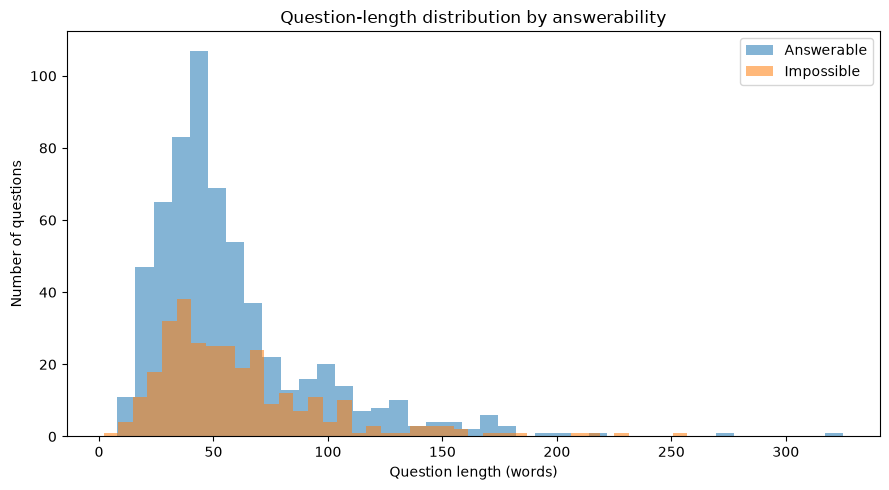

In [26]:
plt.figure(figsize=(9, 5))
for label, group in qa.groupby("is_impossible"):
    readable = "Impossible" if label else "Answerable"
    plt.hist(group["question_words"], bins=40, alpha=0.55, label=readable)
plt.xlabel("Question length (words)")
plt.ylabel("Number of questions")
plt.title("Question-length distribution by answerability")
plt.legend()
plt.tight_layout()
plt.show()

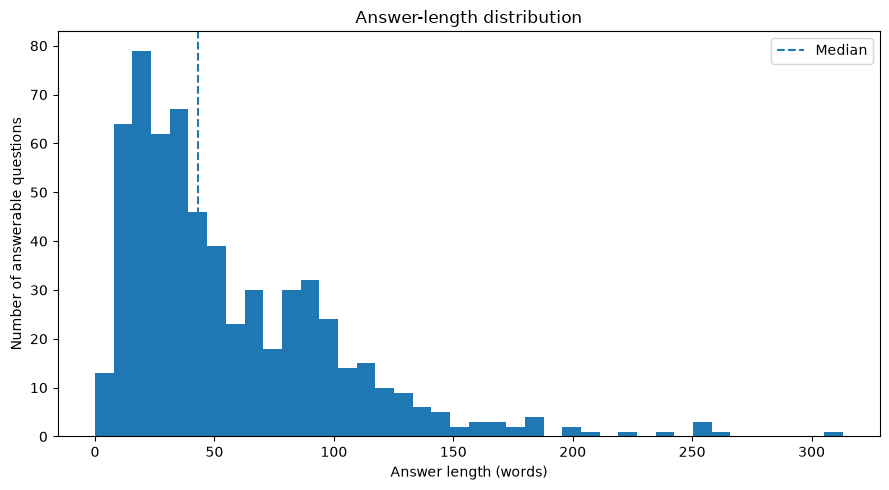

In [27]:
plt.figure(figsize=(9, 5))
plt.hist(possible["answer_words"], bins=40)
plt.axvline(possible["answer_words"].median(), linestyle="--", label="Median")
plt.xlabel("Answer length (words)")
plt.ylabel("Number of answerable questions")
plt.title("Answer-length distribution")
plt.legend()
plt.tight_layout()
plt.show()

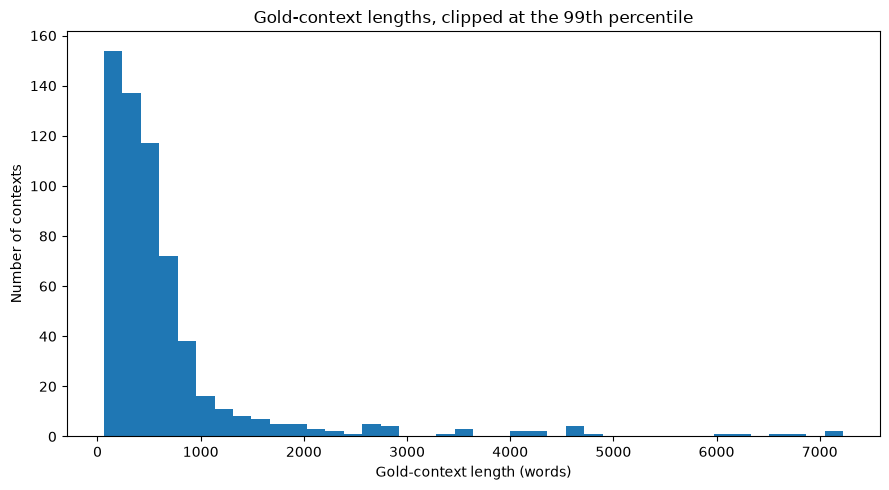

99th percentile: 7,226 words
Maximum: 28,214 words


In [31]:
context_p99 = possible["context_words"].quantile(0.99)
plt.figure(figsize=(9, 5))
plt.hist(possible.loc[possible["context_words"] <= context_p99, "context_words"], bins=40)
plt.xlabel("Gold-context length (words)")
plt.ylabel("Number of contexts")
plt.title("Gold-context lengths, clipped at the 99th percentile")
plt.tight_layout()
plt.show()

print(f"99th percentile: {context_p99:,.0f} words")
print(f"Maximum: {possible['context_words'].max():,.0f} words")

## Look at the documents corpus


In [32]:
corpus_rows = []

with zipfile.ZipFile(CORPUS_ZIP) as z:
    for member in corpus_members:
        raw = z.read(member)
        text = raw.decode("utf-8", errors="replace")
        filename = Path(member).name
        prefix_match = re.match(r"^[A-Za-z]+", filename)
        corpus_rows.append({
            "filename": filename,
            "prefix": prefix_match.group(0) if prefix_match else "other",
            "chars": len(text),
            "words": word_count(text),
            "starts_with_title": text.startswith("Title:"),
            "sha256": hashlib.sha256(raw).hexdigest(),
        })

corpus_meta = pd.DataFrame(corpus_rows)

corpus_quality = pd.Series({
    "Documents": len(corpus_meta),
    "Unique filenames": corpus_meta["filename"].nunique(),
    "Empty documents": (corpus_meta["chars"] == 0).sum(),
    "Documents beginning with 'Title:'": corpus_meta["starts_with_title"].sum(),
    "Exact duplicate-content groups": corpus_meta.groupby("sha256").size().gt(1).sum(),
    "Extra documents due to exact duplicate content": corpus_meta.duplicated("sha256").sum(),
})
display(corpus_quality.to_frame("value"))

corpus_length_summary = corpus_meta["words"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).to_frame("corpus_words").T
display(corpus_length_summary.round(1))

,value
Documents,28481
Unique filenames,28481
Empty documents,0
Documents beginning with 'Title:',28481
Exact duplicate-content groups,2
Extra documents due to exact duplicate content,3


,count,mean,std,min,25%,50%,75%,95%,99%,max
corpus_words,28481.0,533.7,413.2,28.0,301.0,450.0,681.0,1185.0,1489.4,28214.0


,documents,share_pct
filename_prefix,,
swg,27511,96.59
nas,410,1.44
isg,295,1.04
ssg,186,0.65
ibm,79,0.28


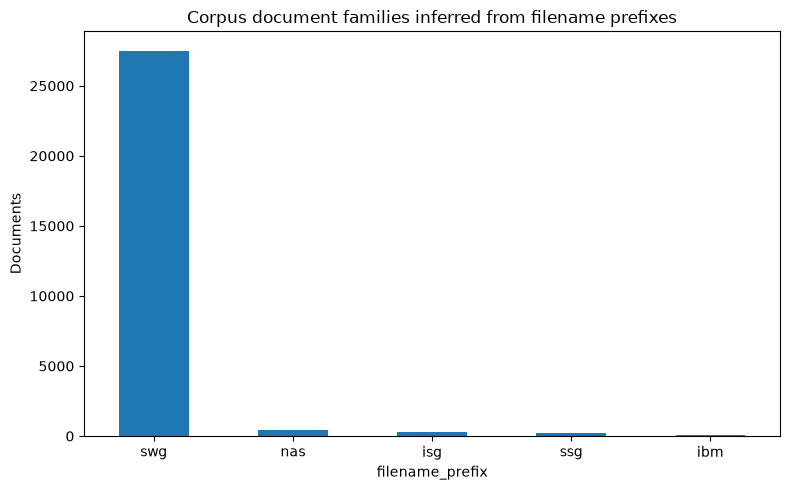

In [33]:
source_counts = corpus_meta["prefix"].value_counts().rename_axis("filename_prefix").to_frame("documents")
source_counts["share_pct"] = 100 * source_counts["documents"] / len(corpus_meta)
display(source_counts.round(2))

plt.figure(figsize=(8, 5))
source_counts["documents"].plot(kind="bar")
plt.ylabel("Documents")
plt.title("Corpus document families inferred from filename prefixes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

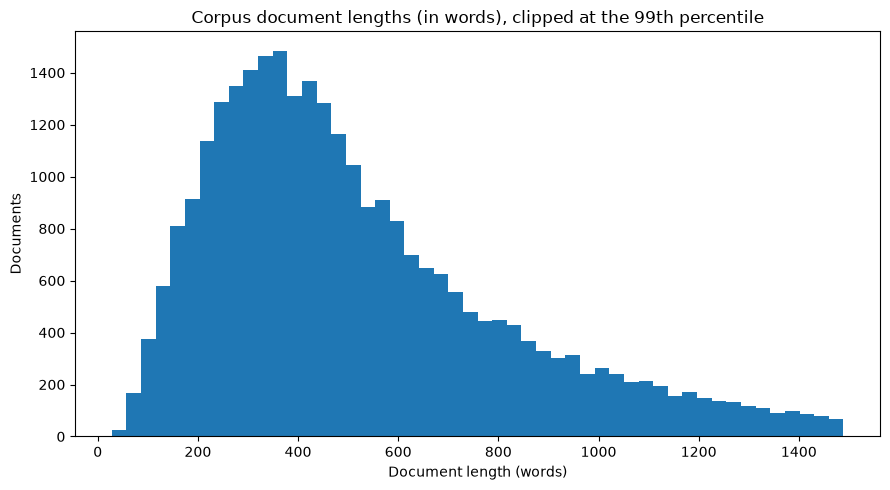

Longest documents:


,filename,words,chars
23544,swg27048240.txt,28214,178392
19565,swg27020885.txt,22651,140270
10818,swg24039742.txt,16347,107496
20497,swg24043263.txt,11210,76601
7570,swg27023600.txt,7568,51068


In [35]:
corpus_p99 = corpus_meta["words"].quantile(0.99)
plt.figure(figsize=(9, 5))
plt.hist(corpus_meta.loc[corpus_meta["words"] <= corpus_p99, "words"], bins=50)
plt.xlabel("Document length (words)")
plt.ylabel("Documents")
plt.title("Corpus document lengths (in words), clipped at the 99th percentile")
plt.tight_layout()
plt.show()

print("Longest documents:")
display(corpus_meta.nlargest(5, "words")[["filename", "words", "chars"]])

## Connect QA rows to corpus documents

Test whether:

- every labeled context filename exists in the corpus;
- the embedded context text exactly matches the corresponding corpus file;
- gold documents are reused by multiple questions;
- answers are largely copied or paraphrased from their contexts.

In [36]:
corpus_member_by_filename = {Path(name).name: name for name in corpus_members}
used_context_counts = possible["context_filename"].value_counts()
unique_gold_files = set(used_context_counts.index)
missing_gold_files = sorted(unique_gold_files - set(corpus_member_by_filename))

exact_context_matches = 0
answer_substring_flags = []

with zipfile.ZipFile(CORPUS_ZIP) as z:
    for _, row in possible.iterrows():
        corpus_text = z.read(corpus_member_by_filename[row["context_filename"]]).decode(
            "utf-8", errors="replace"
        )
        exact_context_matches += int(corpus_text == row["context_text"])
        answer_substring_flags.append(
            normalize_text(row["answer"]) in normalize_text(row["context_text"])
        )

possible["full_answer_found_in_context"] = answer_substring_flags

linkage_metrics = pd.Series({
    "Answerable QA rows": len(possible),
    "Impossible QA rows": len(impossible),
    "Unique gold-context documents": len(unique_gold_files),
    "Total corpus documents": len(corpus_meta),
    "Gold documents as % of corpus": 100 * len(unique_gold_files) / len(corpus_meta),
    "Gold filenames missing from corpus": len(missing_gold_files),
    "Embedded contexts exactly matching corpus files": exact_context_matches,
    "Answers found as normalized full substrings": possible["full_answer_found_in_context"].sum(),
})
display(linkage_metrics.to_frame("value").round(2))

,value
Answerable QA rows,610.00
Impossible QA rows,300.00
Unique gold-context documents,496.00
Total corpus documents,28481.00
Gold documents as % of corpus,1.74
Gold filenames missing from corpus,0.00
Embedded contexts exactly matching corpus files,610.00
Answers found as normalized full substrings,603.00


In [39]:
print("Most reused gold documents:")
display(used_context_counts.head(10).to_frame("number_of_questions"))

non_copied = possible.loc[
    ~possible["full_answer_found_in_context"],
    ["id", "context_filename", "answer", "context_text"]
].copy()
non_copied["answer"] = non_copied["answer"].map(lambda x: shorten(x, 240))
non_copied["context_text"] = non_copied["context_text"].map(lambda x: shorten(x, 240))

print(f"\nStrict non-copied cases: {len(non_copied)}")
display(non_copied.head(5))

Most reused gold documents:


,number_of_questions
context_filename,
swg21592093.txt,9
swg21507587.txt,6
swg21163875.txt,5
swg21638268.txt,3
swg21674924.txt,3
swg1PI47826.txt,3
swg21406783.txt,3
swg22009818.txt,3
swg21511831.txt,3



Strict non-copied cases: 7


,id,context_filename,answer,context_text
629,DEV_Q029,swg21496354.txt,Configure the WebSphere Application Server data source connection pool so as to eliminate occurrences of StaleConnec...,Title: IBM JRules or ODM module fails to access database with StaleConnectionException - United States Text: TECHNOT...
729,DEV_Q129,swg21962588.txt,CVEID: CVE-2015-0410 DESCRIPTION: An unspecified vulnerability related to the Security component could allow a remot...,Title: IBM Security Bulletin: Multiple vulnerabilities in IBM Java SDK affect IBM OS Images for Red Hat Linux System...
756,DEV_Q156,swg21998655.txt,CVEID: CVE-2016-9693 DESCRIPTION: IBM Business Process Manager has a file download capability that is vulnerable to ...,Title: IBM Security Bulletin: Malicious File Download vulnerability in IBM Business Process Manager (BPM) and WebSph...
760,DEV_Q160,swg21163875.txt,"The HTTP Session time-out can be set in the following places: From the Administrative Console at the server, Enterpr...",Title: IBM HTTP Session time-out settings and overwrite precedence rules - United States Text: WebSphere http sessio...
780,DEV_Q180,swg21964873.txt,CVEID: CVE-2015-1920 DESCRIPTION: WebSphere Application Server could allow a remote attacker to execute arbitrary co...,Title: IBM Security Bulletin: Security Vulnerability in IBM PureApplication System. (CVE-2015-1920) - United States ...


### Observations

- All gold filenames correspond to existing files in the corpus.
- Embedded context text matches the raw corpus files exactly.
- Only a small fraction of the corpus is used as gold documents by labeled questions.
- Most answer are copied contexts from corresponding documents.


## Lexical viewpoint


In [40]:
def top_ngrams(texts, ngram_range=(1, 1), n=15, min_df=2):
    vectorizer = CountVectorizer(
        stop_words="english",
        lowercase=True,
        ngram_range=ngram_range,
        min_df=min_df,
        token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z0-9_/-]{2,}\b",
    )
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    order = counts.argsort()[::-1][:n]
    return pd.DataFrame({"term": terms[order], "count": counts[order]})

question_terms = top_ngrams(qa["question"], (1, 1), n=15)
question_bigrams = top_ngrams(qa["question"], (2, 2), n=15)

print("Top question terms")
display(question_terms)
print("Top question bigrams")
display(question_bigrams)

Top question terms


,term,count
0,ibm,606
1,server,407
2,websphere,373
3,error,364
4,security,313
5,java,300
6,application,225
7,bulletin,219
8,need,196
9,message,174


Top question bigrams


,term,count
0,security bulletin,219
1,need understand,130
2,understand details,128
3,details regarding,128
4,com ibm,122
5,application server,107
6,regarding security,106
7,websphere application,96
8,help security,91
9,ibm websphere,71


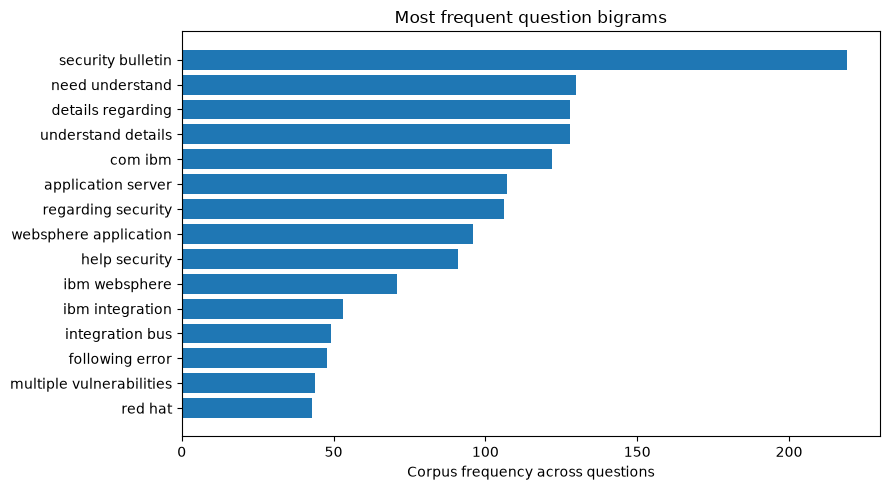

In [41]:
plt.figure(figsize=(9, 5))
plot_data = question_bigrams.sort_values("count")
plt.barh(plot_data["term"], plot_data["count"])
plt.xlabel("Corpus frequency across questions")
plt.title("Most frequent question bigrams")
plt.tight_layout()
plt.show()